In [6]:
import os
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

DATA_PATH = "../data/processed/city_day_cleaned.csv"
MODEL_DIR = "../models"
RESULTS_DIR = "../results"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])

print("Dataset:", df.shape)

Dataset: (24850, 29)


In [7]:
TARGET = "AQI"

DROP_FOR_MODEL = [
    "AQI",
    "AQI_Bucket",
    "Date"
]

X = df.drop(columns=DROP_FOR_MODEL)
y = df[TARGET]

train_mask = df["Date"] < "2020-01-01"

X_train = X.loc[train_mask].copy()
X_test = X.loc[~train_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[~train_mask].copy()

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (20429, 26)
X_test : (4421, 26)
y_train: (20429,)
y_test : (4421,)


In [8]:
categorical_features = ["City", "Season"]

numeric_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", TargetEncoder(smooth=500.0, cv=5, random_state=42))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numeric_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)

Numeric features: 24
Categorical features: ['City', 'Season']


In [9]:
models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

results = []
trained_pipelines = {}

for name, model in models.items():

    print(f"Training {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_pipelines[name] = pipe

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df)
results_df.to_csv(
    os.path.join(RESULTS_DIR, "model_comparison.csv"),
    index=False
)

Training Linear Regression...


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Training Random Forest...


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Training Extra Trees...


...

Training Gradient Boosting...


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Training XGBoost...


c:\Users\asus\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


,Model,MAE,RMSE,R2
0,Random Forest,15.695343,25.950115,0.903281
1,Gradient Boosting,16.240812,26.683424,0.897737
2,Extra Trees,19.219511,31.181721,0.860352
3,XGBoost,19.977465,32.231421,0.850791
4,Linear Regression,23.736568,39.821745,0.772241


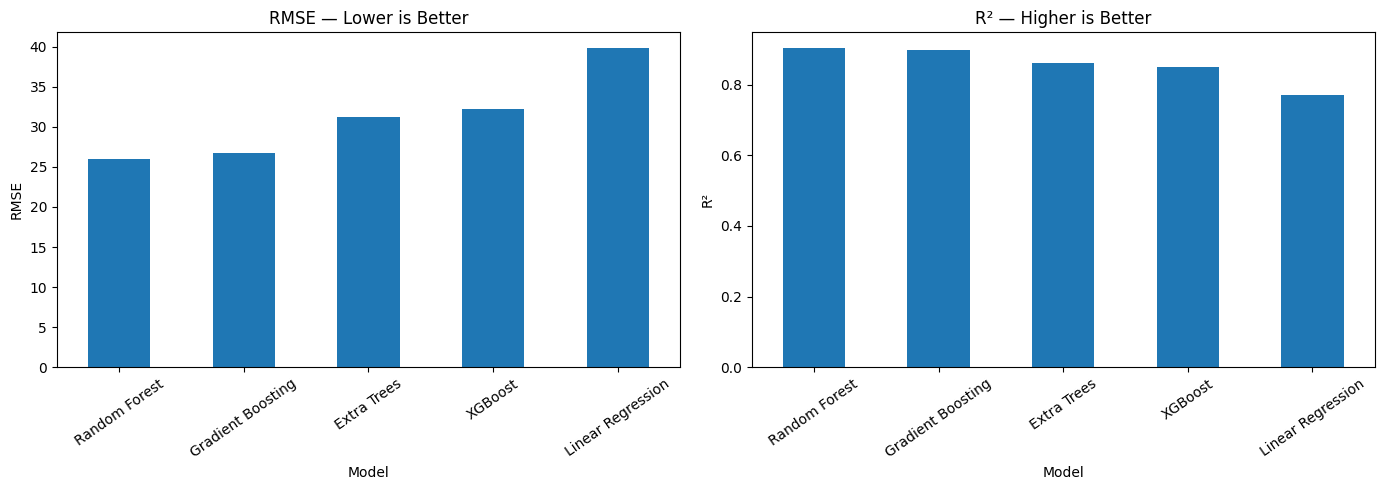

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    ax=axes[0],
    legend=False
)
axes[0].set_title("RMSE — Lower is Better")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=35)

results_df.plot(
    x="Model",
    y="R2",
    kind="bar",
    ax=axes[1],
    legend=False
)
axes[1].set_title("R² — Higher is Better")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

In [11]:
best_name = results_df.iloc[0]["Model"]
best_pipeline = trained_pipelines[best_name]

model_path = os.path.join(MODEL_DIR, "aqi_model.pkl")
joblib.dump(best_pipeline, model_path)

metadata = {
    "model_name": best_name,
    "target": TARGET,
    "train_start": str(df.loc[train_mask, "Date"].min().date()),
    "train_end": str(df.loc[train_mask, "Date"].max().date()),
    "test_start": str(df.loc[~train_mask, "Date"].min().date()),
    "test_end": str(df.loc[~train_mask, "Date"].max().date()),
    "mae": float(results_df.iloc[0]["MAE"]),
    "rmse": float(results_df.iloc[0]["RMSE"]),
    "r2": float(results_df.iloc[0]["R2"])
}

with open(
    os.path.join(MODEL_DIR, "model_metadata.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(metadata, f, indent=4)

print("Best model:", best_name)
print("Saved:", model_path)
display(pd.DataFrame([metadata]))

Best model: Random Forest
Saved: ../models\aqi_model.pkl


,model_name,target,train_start,train_end,test_start,test_end,mae,rmse,r2
0,Random Forest,AQI,2015-01-01,2019-12-31,2020-01-01,2020-07-01,15.695343,25.950115,0.903281


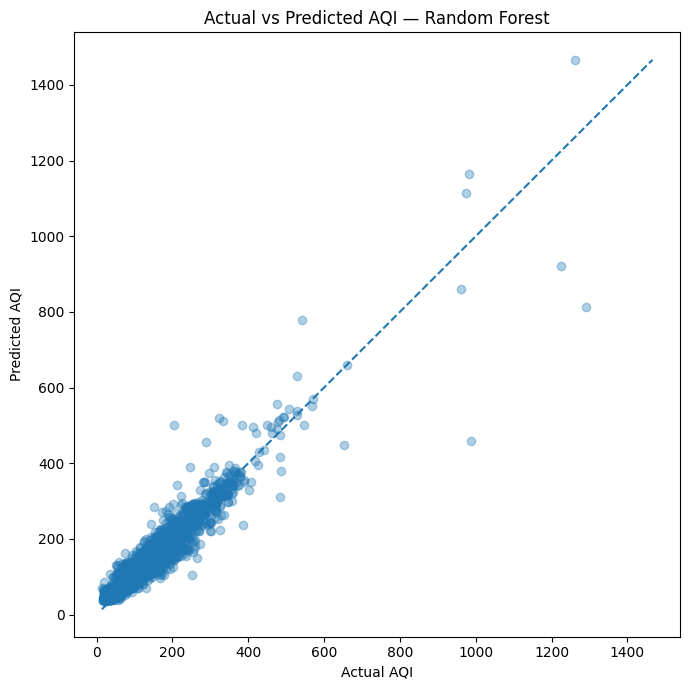

In [12]:
pred = best_pipeline.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.35)

lims = [
    min(y_test.min(), pred.min()),
    max(y_test.max(), pred.max())
]

plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title(f"Actual vs Predicted AQI — {best_name}")
plt.tight_layout()
plt.show()

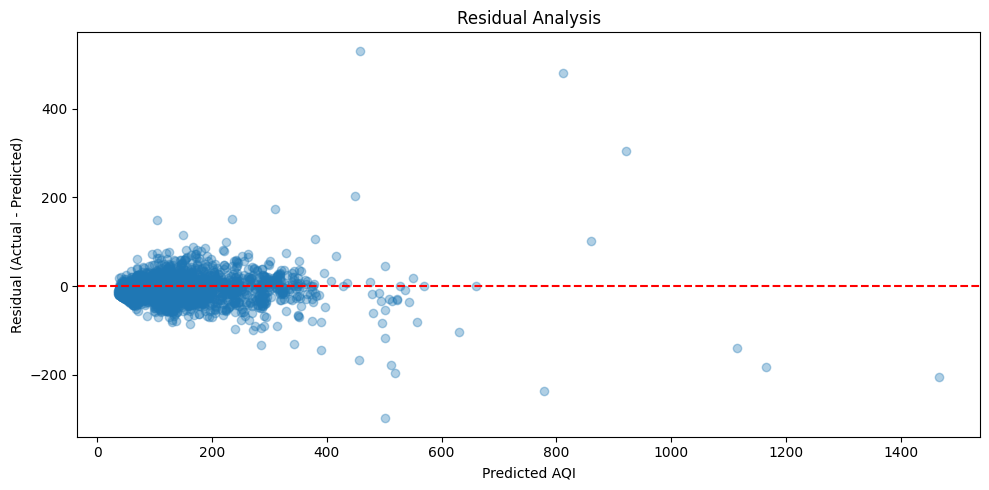

Mean residual: -6.283511271959587
Median residual: -6.633333333333326


In [15]:
residuals = y_test.to_numpy() - pred

plt.figure(figsize=(10, 5))
plt.scatter(pred, residuals, alpha=0.35)
plt.axhline(0, linestyle="--",color='red')
plt.xlabel("Predicted AQI")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis")
plt.tight_layout()
plt.show()

print("Mean residual:", residuals.mean())
print("Median residual:", np.median(residuals))

In [16]:
eval_df = df.loc[~train_mask, ["City", "AQI"]].copy()
eval_df["Prediction"] = pred
eval_df["AbsoluteError"] = (
    eval_df["AQI"] - eval_df["Prediction"]
).abs()

city_eval = (
    eval_df.groupby("City")
    .agg(
        MAE=("AbsoluteError", "mean"),
        Samples=("AQI", "size")
    )
    .sort_values("MAE")
)

display(city_eval)
city_eval.to_csv(
    os.path.join(RESULTS_DIR, "city_wise_evaluation.csv")
)

,MAE,Samples
City,,
Bengaluru,6.290219,183
Thiruvananthapuram,8.049836,183
Mumbai,8.134007,183
Ernakulam,9.470763,153
Kolkata,9.829745,183
Hyderabad,10.344444,183
Coimbatore,11.372244,156
Bhopal,12.487881,173
Jaipur,13.047250,183


,Feature,Importance
0,num__PM2.5,0.470141
6,num__CO,0.366919
2,num__NO,0.032628
1,num__PM10,0.020929
21,num__Particulate_Load,0.008410
8,num__O3,0.007926
23,num__Total_Pollution,0.007025
4,num__NOx,0.004806
7,num__SO2,0.003976
22,num__Gas_Pollution,0.003583


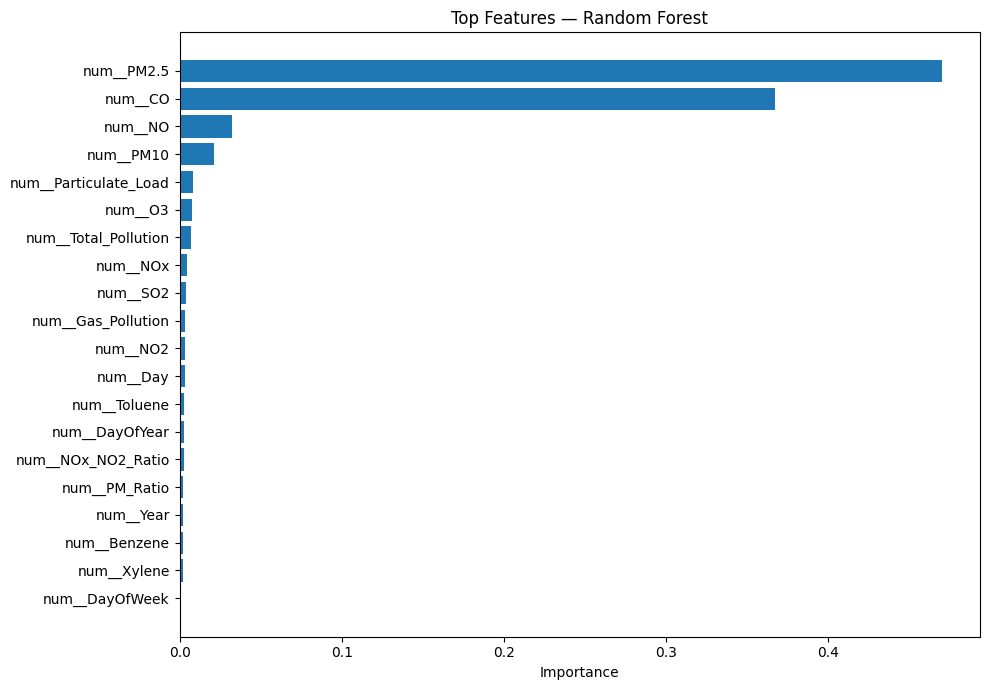

In [17]:
from sklearn.inspection import permutation_importance

if best_name in ["Random Forest", "Extra Trees", "Gradient Boosting", "XGBoost"]:
    model = best_pipeline.named_steps["model"]
    fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

    feature_names = fitted_preprocessor.get_feature_names_out()

    importances = model.feature_importances_

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": importances
        })
        .sort_values("Importance", ascending=False)
        .head(20)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1]
    )
    plt.title(f"Top Features — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    importance_df.to_csv(
        os.path.join(RESULTS_DIR, "feature_importance.csv"),
        index=False
    )
else:
    print("Use permutation importance for the selected non-tree model.")